In [1]:
import pandas as pd

In [7]:
df = pd.read_csv("data/Telco-Customer-Churn.csv")

In [8]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df["TotalCharges"].value_counts().head()

TotalCharges
20.2     11
         11
19.75     9
19.65     8
19.9      8
Name: count, dtype: int64

In [9]:
(df["TotalCharges"].str.strip() == "").sum()

np.int64(11)

In [10]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [11]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [12]:
df["TotalCharges"].dtype

dtype('float64')

In [13]:
df[df["TotalCharges"].isnull()][
    ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,NaN,No
753,0,20.25,NaN,No
936,0,80.85,NaN,No
1082,0,25.75,NaN,No
1340,0,56.05,NaN,No
3331,0,19.85,NaN,No
3826,0,25.35,NaN,No
4380,0,20.00,NaN,No
5218,0,19.70,NaN,No
6670,0,73.35,NaN,No


In [15]:
df = df.dropna(subset=["TotalCharges"])

In [16]:
print("Dataset shape:", df.shape)
print("Missing TotalCharges:", df["TotalCharges"].isnull().sum())

Dataset shape: (7032, 21)
Missing TotalCharges: 0


In [17]:
df = df.drop("customerID", axis=1)

In [18]:
print(df.shape)
print(df.columns)

(7032, 20)
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [19]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [20]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [21]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

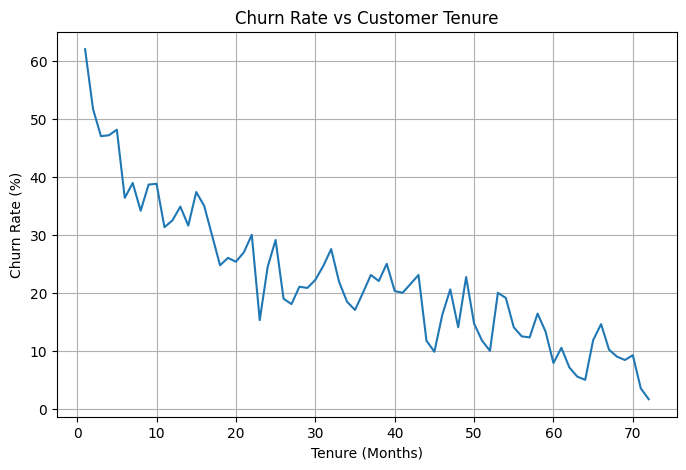

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

df.groupby("tenure")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
).plot()

plt.xlabel("Tenure (Months)")
plt.ylabel("Churn Rate (%)")
plt.title("Churn Rate vs Customer Tenure")
plt.grid(True)
plt.show()

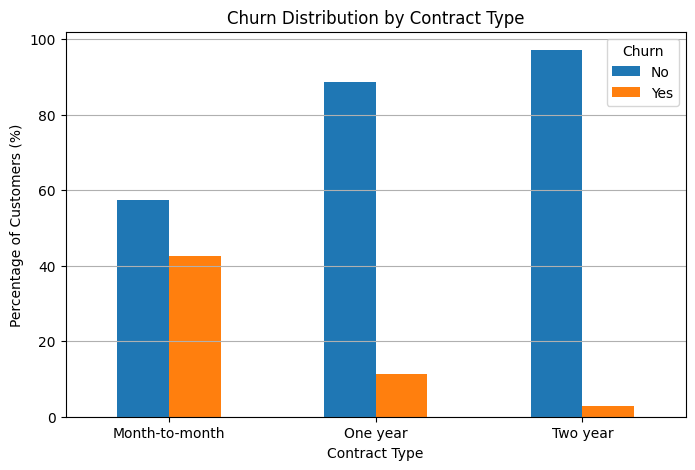

In [23]:
churn_by_contract = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

churn_by_contract.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Contract Type")
plt.ylabel("Percentage of Customers (%)")
plt.title("Churn Distribution by Contract Type")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.grid(axis="y")
plt.show()

In [24]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

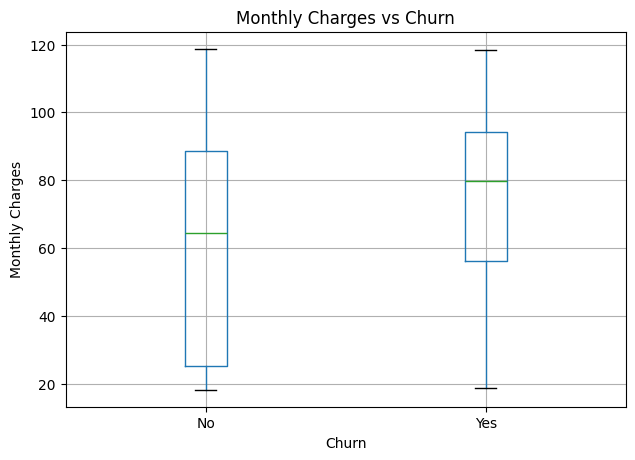

In [25]:
df.boxplot(
    column="MonthlyCharges",
    by="Churn",
    figsize=(7, 5)
)

plt.title("Monthly Charges vs Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [26]:
churn_by_payment = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_by_payment)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


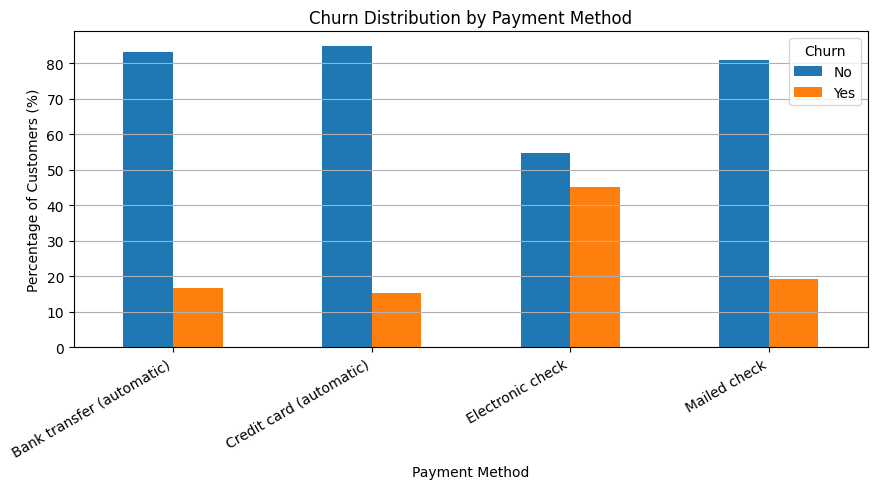

In [27]:
churn_by_payment.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.xlabel("Payment Method")
plt.ylabel("Percentage of Customers (%)")
plt.title("Churn Distribution by Payment Method")
plt.xticks(rotation=30, ha="right")
plt.legend(title="Churn")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [28]:
churn_by_internet = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(churn_by_internet)

Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


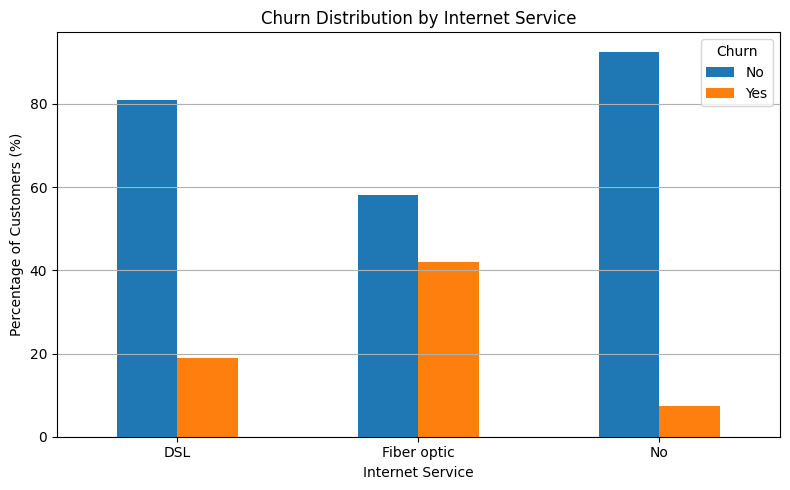

In [29]:
churn_by_internet.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Internet Service")
plt.ylabel("Percentage of Customers (%)")
plt.title("Churn Distribution by Internet Service")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

In [41]:
X = df.drop("Churn", axis=1)

In [42]:
y = df["Churn"]

In [43]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [44]:
y = y.map({"No": 0, "Yes": 1})

In [45]:
print(y.value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [47]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target:")
print(y_test.value_counts(normalize=True) * 100)

Training data: (5625, 19)
Testing data: (1407, 19)

Training target:
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

Testing target:
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


In [48]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col for col in X.columns
    if col not in numeric_features
]

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [49]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [51]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [52]:
print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (5625, 19)
Processed training shape: (5625, 45)
Original testing shape: (1407, 19)
Processed testing shape: (1407, 45)


In [53]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

In [54]:
logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [55]:
logistic_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [56]:
y_pred = logistic_pipeline.predict(X_test)

In [57]:
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [58]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.7313432835820896
Precision: 0.49658703071672355
Recall   : 0.7780748663101604
F1-score : 0.60625
ROC-AUC  : 0.8334001998229548


[[738 295]
 [ 83 291]]


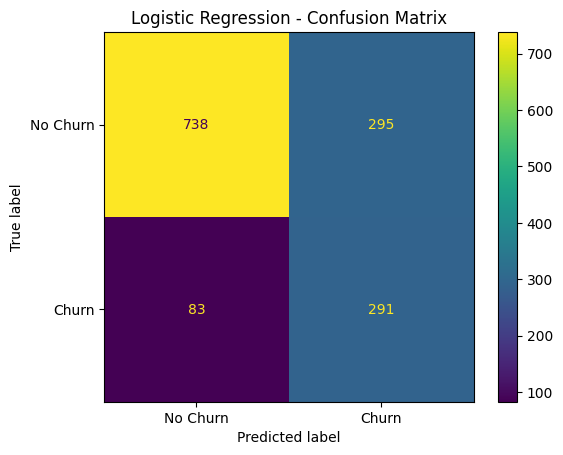

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

[[738 295]
 [ 83 291]]


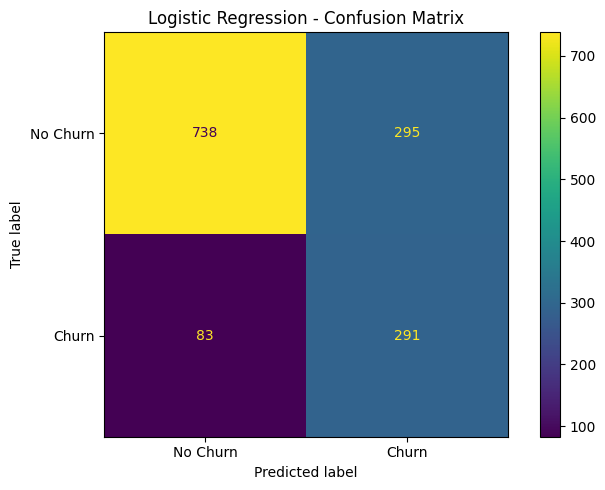

In [64]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

print(cm)

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
).plot(ax=ax)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()



plt.show()

In [65]:
from sklearn.ensemble import RandomForestClassifier

In [66]:
random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [67]:
random_forest_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [68]:
random_forest_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [69]:
rf_pred = random_forest_pipeline.predict(X_test)

rf_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [70]:
print("Random Forest Results")
print("--------------------")
print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1-score :", f1_score(y_test, rf_pred))
print("ROC-AUC  :", roc_auc_score(y_test, rf_prob))

Random Forest Results
--------------------
Accuracy : 0.7711442786069652
Precision: 0.5702702702702702
Recall   : 0.5641711229946524
F1-score : 0.5672043010752689
ROC-AUC  : 0.8105215068514423


In [71]:
import xgboost
print(xgboost.__version__)

3.4.1


In [72]:
from xgboost import XGBClassifier

In [73]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [74]:
xgb_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [75]:
xgb_pred = xgb_pipeline.predict(X_test)

xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [76]:
print("XGBoost Results")
print("----------------")
print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1-score :", f1_score(y_test, xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, xgb_prob))

XGBoost Results
----------------
Accuracy : 0.7775408670931059
Precision: 0.5721040189125296
Recall   : 0.6470588235294118
F1-score : 0.6072772898368883
ROC-AUC  : 0.834247894352672


In [77]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 4],
    "model__learning_rate": [0.05, 0.1]
}

In [78]:
from sklearn.model_selection import GridSearchCV

In [79]:
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

In [80]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 4], 'model__n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [81]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1:")
print(grid_search.best_score_)

Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}

Best Cross-Validation F1:
0.6344262687320994


In [82]:
best_xgb_model = grid_search.best_estimator_

In [83]:
tuned_xgb_pred = best_xgb_model.predict(X_test)

tuned_xgb_prob = best_xgb_model.predict_proba(X_test)[:, 1]

In [84]:
print("Tuned XGBoost Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, tuned_xgb_pred))
print("Precision:", precision_score(y_test, tuned_xgb_pred))
print("Recall   :", recall_score(y_test, tuned_xgb_pred))
print("F1-score :", f1_score(y_test, tuned_xgb_pred))
print("ROC-AUC  :", roc_auc_score(y_test, tuned_xgb_prob))

Tuned XGBoost Results
---------------------
Accuracy : 0.7683013503909026
Precision: 0.546875
Recall   : 0.7486631016042781
F1-score : 0.6320541760722348
ROC-AUC  : 0.8359795207355142


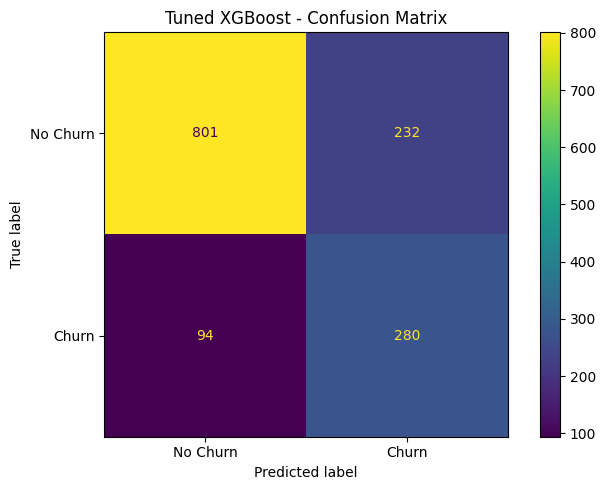

In [85]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_tuned = confusion_matrix(y_test, tuned_xgb_pred)

fig, ax = plt.subplots(figsize=(7, 5))

ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["No Churn", "Churn"]
).plot(ax=ax)

plt.title("Tuned XGBoost - Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "outputs/tuned_xgboost_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

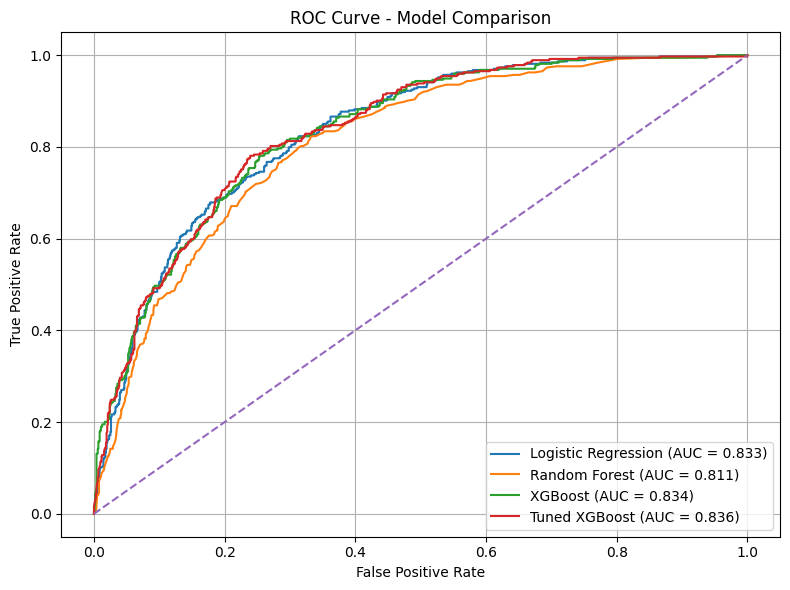

In [86]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, tuned_xgb_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr, lr_tpr,
    label=f"Logistic Regression (AUC = {auc(lr_fpr, lr_tpr):.3f})"
)

plt.plot(
    rf_fpr, rf_tpr,
    label=f"Random Forest (AUC = {auc(rf_fpr, rf_tpr):.3f})"
)

plt.plot(
    xgb_fpr, xgb_tpr,
    label=f"XGBoost (AUC = {auc(xgb_fpr, xgb_tpr):.3f})"
)

plt.plot(
    tuned_fpr, tuned_tpr,
    label=f"Tuned XGBoost (AUC = {auc(tuned_fpr, tuned_tpr):.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "outputs/roc_curve_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
from sklearn.svm import SVC

In [88]:
svc_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        probability=True,
        random_state=42
    ))
])

In [89]:
svc_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [90]:
svc_pred = svc_pipeline.predict(X_test)

svc_prob = svc_pipeline.predict_proba(X_test)[:, 1]

In [91]:
print("SVC Results")
print("-----------")
print("Accuracy :", accuracy_score(y_test, svc_pred))
print("Precision:", precision_score(y_test, svc_pred))
print("Recall   :", recall_score(y_test, svc_pred))
print("F1-score :", f1_score(y_test, svc_pred))
print("ROC-AUC  :", roc_auc_score(y_test, svc_prob))

SVC Results
-----------
Accuracy : 0.7533759772565742
Precision: 0.5262135922330097
Recall   : 0.7245989304812834
F1-score : 0.609673790776153
ROC-AUC  : 0.8078684171019459


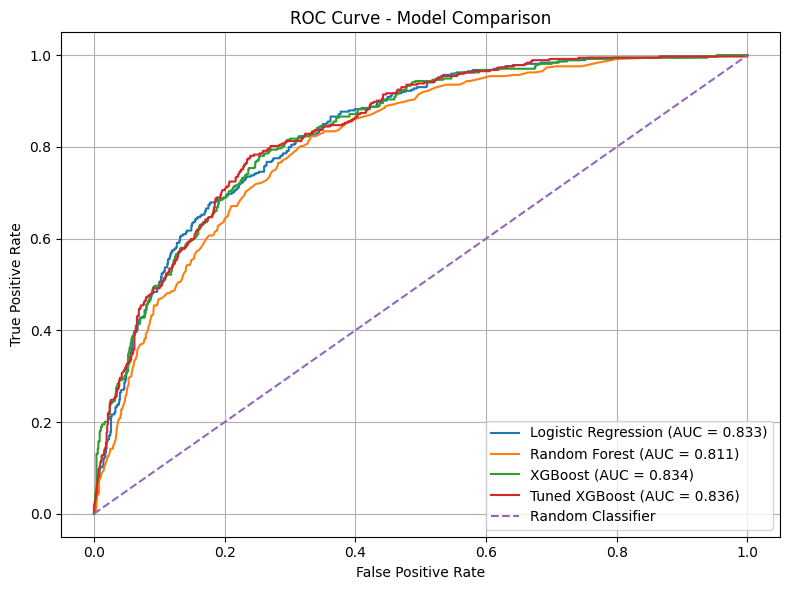

In [92]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# ROC curve values
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)
tuned_fpr, tuned_tpr, _ = roc_curve(y_test, tuned_xgb_prob)

# Calculate AUC
lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)
xgb_auc = auc(xgb_fpr, xgb_tpr)
tuned_auc = auc(tuned_fpr, tuned_tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    lr_fpr, lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    rf_fpr, rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    xgb_fpr, xgb_tpr,
    label=f"XGBoost (AUC = {xgb_auc:.3f})"
)

plt.plot(
    tuned_fpr, tuned_tpr,
    label=f"Tuned XGBoost (AUC = {tuned_auc:.3f})"
)

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Model Comparison")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "outputs/roc_curve_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [93]:
results_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, tuned_xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred),
        precision_score(y_test, tuned_xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred),
        recall_score(y_test, tuned_xgb_pred)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred),
        f1_score(y_test, tuned_xgb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob),
        roc_auc_score(y_test, tuned_xgb_prob)
    ]
})

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.731343,0.496587,0.778075,0.606250,0.833400
1,Random Forest,0.771144,0.570270,0.564171,0.567204,0.810522
2,XGBoost,0.777541,0.572104,0.647059,0.607277,0.834248
3,Tuned XGBoost,0.768301,0.546875,0.748663,0.632054,0.835980


In [94]:
results_df.to_csv(
    "outputs/model_comparison.csv",
    index=False
)

In [95]:
feature_names = best_xgb_model.named_steps["preprocessor"].get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 45
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No'
 'cat__OnlineBackup_No internet service' 'cat__OnlineBackup_Yes'
 'cat__DeviceProtection_No' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No'
 'cat__TechSupport_No internet service' 'cat__TechSupport_Yes'
 'cat__StreamingTV_No' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No'
 'cat__StreamingMovies_No internet service' 'cat__StreamingMovies_Yes'

In [96]:
import xgboost
import shap

print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)

XGBoost: 3.4.1
SHAP: 0.52.0


In [97]:
import shap
import xgboost

print("XGBoost:", xgboost.__version__)
print("SHAP:", shap.__version__)

XGBoost: 3.4.1
SHAP: 0.52.0


In [98]:
X_test_processed = best_xgb_model.named_steps["preprocessor"].transform(X_test)

print("Processed test shape:", X_test_processed.shape)

Processed test shape: (1407, 45)


In [99]:
explainer = shap.TreeExplainer(
    best_xgb_model.named_steps["model"]
)

print("SHAP explainer created successfully!")

SHAP explainer created successfully!


In [100]:
shap_values = explainer.shap_values(X_test_processed)

print("SHAP values calculated!")
print("Shape:", shap_values.shape)

SHAP values calculated!
Shape: (1407, 45)


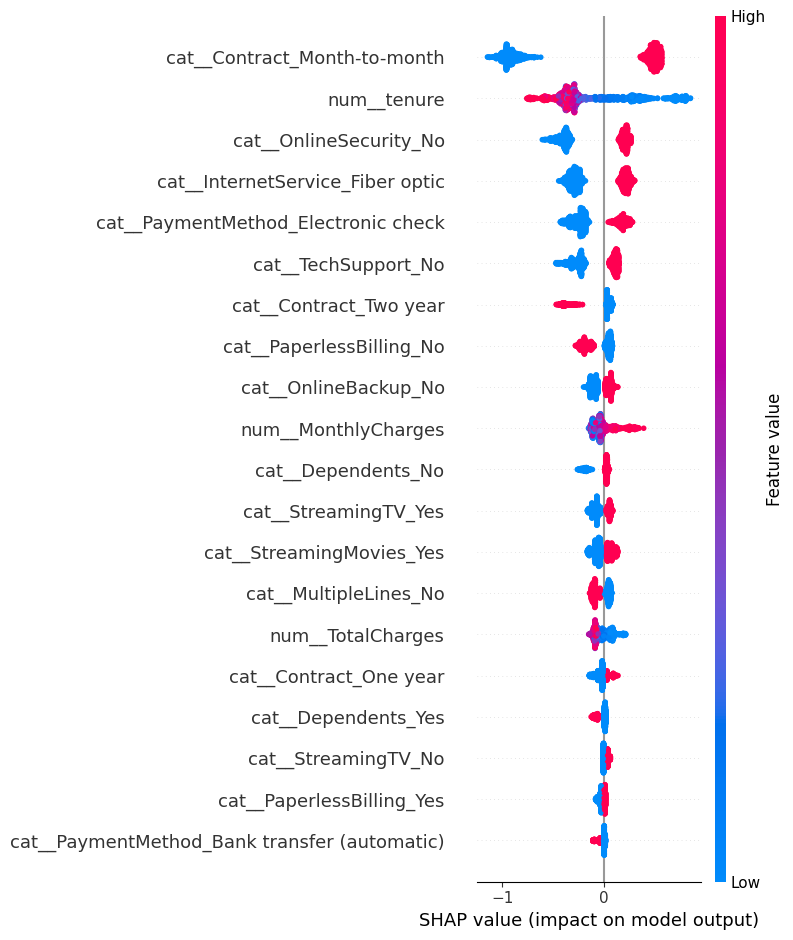

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

shap.summary_plot(
    shap_values,
    X_test_processed,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()
plt.savefig(
    "outputs/shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [102]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculate mean absolute SHAP value for each feature
mean_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_SHAP": mean_shap
})

# Sort and select top 10
shap_importance = (
    shap_importance
    .sort_values("Mean_SHAP", ascending=False)
    .head(10)
)

print(shap_importance)

                                Feature  Mean_SHAP
36         cat__Contract_Month-to-month   0.682108
1                           num__tenure   0.359223
18               cat__OnlineSecurity_No   0.306074
16     cat__InternetService_Fiber optic   0.260679
43  cat__PaymentMethod_Electronic check   0.232887
27                  cat__TechSupport_No   0.189161
38               cat__Contract_Two year   0.125118
39             cat__PaperlessBilling_No   0.104282
21                 cat__OnlineBackup_No   0.079997
2                   num__MonthlyCharges   0.079980


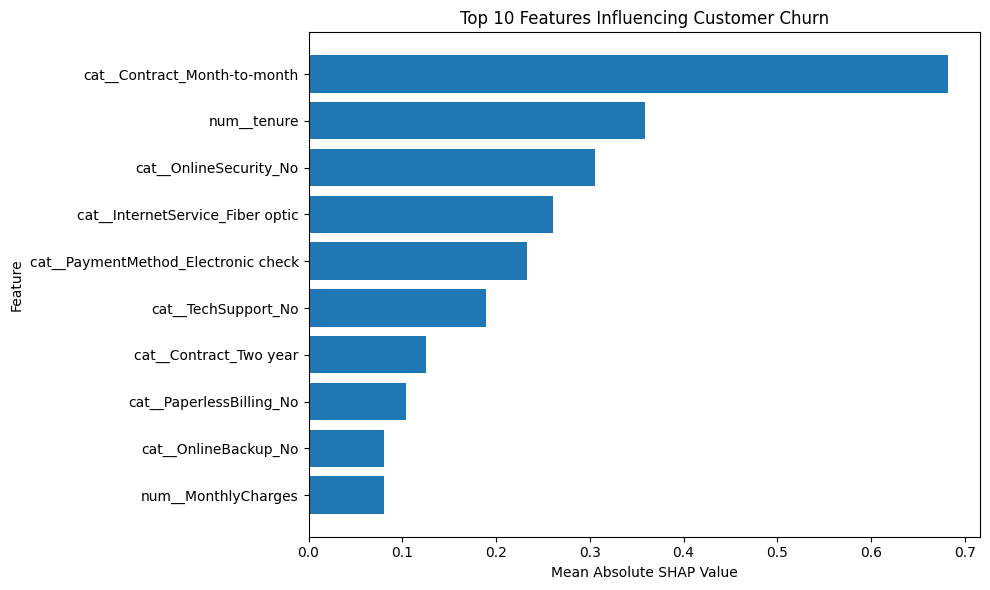

In [103]:
plt.figure(figsize=(10, 6))

plt.barh(
    shap_importance["Feature"][::-1],
    shap_importance["Mean_SHAP"][::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Customer Churn")

plt.tight_layout()

plt.savefig(
    "outputs/shap_top10_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [104]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    best_xgb_model,
    "models/tuned_xgboost_pipeline.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [105]:
import os

print(os.path.exists("models/tuned_xgboost_pipeline.pkl"))

True
